# Обучение и подбор параметров моделей ценообразования

Этот ноутбук показывает, **как готовятся данные, как подбираются параметры моделей
(линейная регрессия и LightGBM) и какими метриками оценивается качество прогноза спроса**
в проекте DinamicPricing.

Структура:
1. Загрузка и обзор данных (EDA)
2. Train/test split (почему именно временной, а не случайный)
3. Базовая модель — линейная регрессия (`Sales ≈ A − B·Price`)
4. Модель LightGBM: признаки, подбор гиперпараметров (GridSearchCV + TimeSeriesSplit)
5. Сравнение моделей по метрикам (MAE, RMSE, MAPE, R²)
6. Важность признаков LightGBM
7. Выводы

> Ноутбук самодостаточен: если файла `data/sales_history.csv` нет, он сам вызовет
> `generator/generate_data.py`, чтобы создать синтетическую историю.


In [1]:
import sys
from pathlib import Path
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor

ROOT = Path.cwd()
if not (ROOT / "model").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT))

DATA_PATH = ROOT / "data" / "sales_history.csv"
if not DATA_PATH.exists():
    subprocess.run([sys.executable, str(ROOT / "generator" / "generate_data.py")], check=True)

pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42


## 1. Загрузка и обзор данных

Берём синтетическую историю продаж (та же, что использует Streamlit-приложение).
Для демонстрации обучения модели на уровне SKU выбираем одну пару **товар + магазин**
— именно так модели обучаются и в самом приложении (`fit_lightgbm_sales_model` вызывается
отдельно для каждой сущности товар×магазин, а не на всём датасете сразу).


In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
print("Размер всего датасета:", df.shape)
print("Период:", df["date"].min().date(), "—", df["date"].max().date())
print("Товары:", df["product"].unique().tolist())
df.head()


Размер всего датасета: (7500, 17)
Период: 2026-03-23 — 2026-06-30
Товары: ['Кофе', 'Сок', 'Молоко', 'Шоколад', 'Хлеб']


,date,store_id,store,store_profile,brand_id,brand,product_id,product,our_price,competitor_1_price,competitor_2_price,competitor_price,is_oos,sales,revenue,cogs,profit
0,2026-03-23,2,ГородПлюс,У дома,1026,BeanCraft,1026,Кофе,528.89,472.005728,422.387662,447.20,False,0.0,0.00,280.0,0.00
1,2026-03-23,2,ГородПлюс,У дома,1022,FruitFlow,1022,Сок,100.41,123.524786,114.971145,119.25,False,218.0,21889.38,80.0,4449.38
2,2026-03-23,2,ГородПлюс,У дома,1017,MilkWay,1017,Молоко,75.69,84.266475,76.056592,80.16,False,394.0,29821.86,60.0,6181.86
3,2026-03-23,2,ГородПлюс,У дома,1027,MorningCup,1027,Кофе,433.58,449.070219,413.450849,431.26,False,123.0,53330.34,280.0,18890.34
4,2026-03-23,2,ГородПлюс,У дома,1025,RoastPoint,1025,Кофе,396.82,447.109690,424.214611,435.66,False,162.0,64284.84,280.0,18924.84


In [3]:
# Выбираем одну пару товар+магазин для прозрачной демонстрации обучения модели
PRODUCT = "Сок"
STORE_ID = df["store_id"].iloc[0]

entity = df[(df["product"] == PRODUCT) & (df["store_id"] == STORE_ID)].sort_values("date").reset_index(drop=True)
print("Строк для обучения:", len(entity))
print("Уникальных цен:", entity["our_price"].nunique())
entity[["date", "our_price", "competitor_price", "is_oos", "sales", "revenue"]].head()


Строк для обучения: 300
Уникальных цен: 284


,date,our_price,competitor_price,is_oos,sales,revenue
0,2026-03-23,100.41,119.25,False,218.0,21889.38
1,2026-03-23,131.52,118.74,False,108.0,14204.16
2,2026-03-23,130.88,115.81,False,98.0,12826.24
3,2026-03-24,101.21,115.82,False,235.0,23784.35
4,2026-03-24,128.98,114.62,False,121.0,15606.58


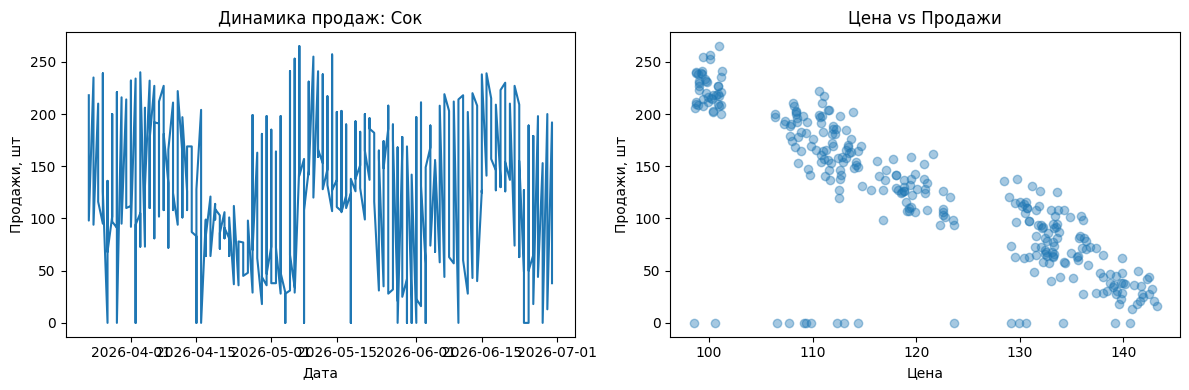

Корреляция цена–продажи: -0.813


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(entity["date"], entity["sales"])
axes[0].set_title(f"Динамика продаж: {PRODUCT}")
axes[0].set_xlabel("Дата"); axes[0].set_ylabel("Продажи, шт")

axes[1].scatter(entity["our_price"], entity["sales"], alpha=0.4)
axes[1].set_title("Цена vs Продажи")
axes[1].set_xlabel("Цена"); axes[1].set_ylabel("Продажи, шт")
plt.tight_layout()
plt.show()

print("Корреляция цена–продажи:", entity["our_price"].corr(entity["sales"]).round(3))


## 2. Train/test split

Это **временной ряд**, поэтому разбивать на train/test нужно **по времени**,
а не случайным образом (`train_test_split` со случайным перемешиванием здесь не подходит —
он привёл бы к "утечке из будущего": модель видела бы дни после тестового периода).

Берём последние ~20% дней как тест, всё, что раньше — как train. Так же стоит поступать
и с подбором гиперпараметров: использовать `TimeSeriesSplit`, а не обычный k-fold.


In [5]:
entity_clean = entity[~entity["is_oos"].astype(str).str.lower().isin(["true", "1"])]
entity_clean = entity_clean[entity_clean["sales"] > 0].copy()

split_idx = int(len(entity_clean) * 0.8)
train_df = entity_clean.iloc[:split_idx].copy()
test_df = entity_clean.iloc[split_idx:].copy()

print(f"Train: {len(train_df)} строк ({train_df['date'].min().date()} — {train_df['date'].max().date()})")
print(f"Test:  {len(test_df)} строк ({test_df['date'].min().date()} — {test_df['date'].max().date()})")


Train: 226 строк (2026-03-23 — 2026-06-10)
Test:  57 строк (2026-06-11 — 2026-06-30)


## 3. Базовая модель: линейная регрессия

`Sales ≈ A − B·Price` — модель, которая используется в приложении для расчёта
оптимальной цены аналитической формулой `P_opt = A / (2B)`.


In [6]:
X_train_lr = train_df[["our_price"]].values
y_train_lr = train_df["sales"].values
X_test_lr = test_df[["our_price"]].values
y_test_lr = test_df["sales"].values

lr = LinearRegression()
lr.fit(X_train_lr, y_train_lr)

A = lr.intercept_
B = -lr.coef_[0]
print(f"A (базовый спрос) = {A:.2f}")
print(f"B (эластичность)  = {B:.4f}")
print(f"Оптимальная цена P_opt = A/(2B) = {A / (2 * B):.2f}")

pred_lr = lr.predict(X_test_lr)


A (базовый спрос) = 671.24
B (эластичность)  = 4.4560
Оптимальная цена P_opt = A/(2B) = 75.32


## 4. Метрики качества

Используем стандартный набор для задачи регрессии спроса:
- **MAE** — средняя абсолютная ошибка в штуках продаж (интерпретируема в бизнес-единицах)
- **RMSE** — чувствительна к крупным ошибкам/выбросам
- **MAPE** — ошибка в % от факта, удобна для сравнения между товарами с разным масштабом продаж
- **R²** — доля объяснённой дисперсии спроса


In [7]:
def regression_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mape = float(np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100)
    r2 = r2_score(y_true, y_pred)
    return {"model": name, "MAE": round(mae, 2), "RMSE": round(rmse, 2), "MAPE_%": round(mape, 2), "R2": round(r2, 3)}

results = []
results.append(regression_metrics(y_test_lr, pred_lr, "LinearRegression (baseline)"))
pd.DataFrame(results)


,model,MAE,RMSE,MAPE_%,R2
0,LinearRegression (baseline),17.15,20.53,25.28,0.902


## 5. LightGBM: признаки и подбор гиперпараметров

Признаки повторяют то, что использует `model/pricing.py::_build_lgbm_training_frame`:
цена, цена конкурента, разница цен, сезонность (день года через sin/cos), день недели,
месяц, лаги продаж (1 и 7 дней) и скользящее среднее за неделю.

Гиперпараметры подбираем через `GridSearchCV` с **`TimeSeriesSplit`** (а не обычной
кросс-валидацией), чтобы при подборе параметров фолды тоже не "заглядывали в будущее".


In [8]:
def build_features(frame: pd.DataFrame) -> pd.DataFrame:
    work = frame.sort_values("date").copy()
    doy = work["date"].dt.dayofyear.astype(float)
    work["doy_sin"] = np.sin(2 * np.pi * doy / 365.0)
    work["doy_cos"] = np.cos(2 * np.pi * doy / 365.0)
    work["dow"] = work["date"].dt.dayofweek.astype(int)
    work["month"] = work["date"].dt.month.astype(int)
    work["price_gap"] = work["our_price"] - work["competitor_price"]
    work["sales_lag1"] = work["sales"].shift(1)
    work["sales_lag7"] = work["sales"].shift(7)
    work["sales_roll7"] = work["sales"].shift(1).rolling(7, min_periods=2).mean()
    return work

FEATURES = ["our_price", "competitor_price", "price_gap", "doy_sin", "doy_cos",
            "dow", "month", "sales_lag1", "sales_lag7", "sales_roll7"]

# Лаги считаем на полной хронологии сущности, чтобы не терять историю на стыке train/test
full_feat = build_features(entity_clean)
train_feat = full_feat[full_feat["date"] <= train_df["date"].max()].dropna(subset=FEATURES)
test_feat = full_feat[full_feat["date"] > train_df["date"].max()].dropna(subset=FEATURES)

X_train, y_train = train_feat[FEATURES], train_feat["sales"]
X_test, y_test = test_feat[FEATURES], test_feat["sales"]
print(f"Train (с признаками): {len(X_train)}, Test: {len(X_test)}")


Train (с признаками): 219, Test: 57


In [9]:
param_grid = {
    "n_estimators": [80, 150, 180],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [15, 31],
    "min_child_samples": [10, 20],
}

tscv = TimeSeriesSplit(n_splits=4)

base_model = LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, subsample=0.85, colsample_bytree=0.85)

grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучший CV MAE:", round(-grid.best_score_, 2))

best_lgbm = grid.best_estimator_
pred_lgbm = best_lgbm.predict(X_test)


Лучшие параметры: {'learning_rate': 0.03, 'min_child_samples': 10, 'n_estimators': 150, 'num_leaves': 31}
Лучший CV MAE: 22.93


In [10]:
results.append(regression_metrics(y_test.values, pred_lgbm, "LightGBM (tuned)"))
comparison = pd.DataFrame(results)
comparison


,model,MAE,RMSE,MAPE_%,R2
0,LinearRegression (baseline),17.15,20.53,25.28,0.902
1,LightGBM (tuned),16.66,20.95,21.39,0.898


## 5b. Альтернативные встроенные методы подбора параметров

`GridSearchCV` перебирает **все** комбинации сетки — надёжно, но дорого при росте числа параметров.
Ниже — два других встроенных в библиотеки способа, которые часто эффективнее.

### RandomizedSearchCV (sklearn)

Пробует заданное число **случайных** комбинаций из тех же диапазонов, а не все подряд.
На практике даёт почти такое же качество, что и `GridSearchCV`, но за заметно меньшее время —
особенно когда сетка большая (как только параметров становится 4+, полный перебор быстро растёт).


In [11]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": randint(50, 250),
    "learning_rate": uniform(0.02, 0.18),
    "num_leaves": randint(8, 64),
    "min_child_samples": randint(5, 40),
}

random_search = RandomizedSearchCV(
    estimator=LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, subsample=0.85, colsample_bytree=0.85),
    param_distributions=param_dist,
    n_iter=25,            # сколько случайных комбинаций пробуем (вместо полного перебора)
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
random_search.fit(X_train, y_train)

print("Лучшие параметры (RandomizedSearchCV):", random_search.best_params_)
print("Лучший CV MAE:", round(-random_search.best_score_, 2))

pred_random = random_search.best_estimator_.predict(X_test)
results.append(regression_metrics(y_test.values, pred_random, "LightGBM (RandomizedSearchCV)"))


Лучшие параметры (RandomizedSearchCV): {'learning_rate': 0.02281455321341491, 'min_child_samples': 13, 'n_estimators': 137, 'num_leaves': 8}
Лучший CV MAE: 22.09


### Early stopping (встроено в LightGBM)

Это отдельный механизм специально для подбора **числа деревьев** (`n_estimators`):
вместо того чтобы перебирать его в сетке, модель обучается с большим запасом деревьев,
а LightGBM сам останавливает обучение, когда ошибка на валидационной части перестаёт падать
заданное число раундов (`stopping_rounds`). Это быстрее и часто точнее, чем гадать число
деревьев руками.

Используем последний кусок train-периода как валидацию для early stopping (без подсматривания в test).


In [12]:
import lightgbm as lgb

val_size = max(20, int(len(X_train) * 0.15))
X_fit, X_val = X_train.iloc[:-val_size], X_train.iloc[-val_size:]
y_fit, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]

es_model = LGBMRegressor(
    n_estimators=1000,          # заведомо много — early stopping сам остановит обучение
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    random_state=RANDOM_STATE,
    subsample=0.85,
    colsample_bytree=0.85,
    verbose=-1,
)
es_model.fit(
    X_fit, y_fit,
    eval_set=[(X_val, y_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
)

print("Остановился на деревьях:", es_model.best_iteration_)

pred_es = es_model.predict(X_test, num_iteration=es_model.best_iteration_)
results.append(regression_metrics(y_test.values, pred_es, "LightGBM (early stopping)"))
pd.DataFrame(results)


Остановился на деревьях: 150


,model,MAE,RMSE,MAPE_%,R2
0,LinearRegression (baseline),17.15,20.53,25.28,0.902
1,LightGBM (tuned),16.66,20.95,21.39,0.898
2,LightGBM (RandomizedSearchCV),15.25,19.18,21.33,0.915
3,LightGBM (early stopping),17.03,21.88,26.01,0.889


### Сверка с прод-тюнингом `_tune_lgbm_params()`

В production-коде `model/pricing.py::_tune_lgbm_params()` используется
`RandomizedSearchCV` с `n_iter=4` (намеренно дёшево, чтобы не замедлять
симуляцию) и распределениями `randint(60,200)`, `randint(8,50)`,
`uniform(0.02,0.13)`, `randint(10,30)`. Параметры по умолчанию при откате:
`{'n_estimators': 180, 'learning_rate': 0.05, 'num_leaves': 31,
`min_child_samples': 20}`.

Ноутбук выше использует `GridSearchCV` с полным перебором 36 комбинаций
(лучшие: `learning_rate=0.05`, `num_leaves=15`, `n_estimators=80`,
`min_child_samples=20`) или `RandomizedSearchCV` с `n_iter=25`.
Совпадение лучших параметров **не гарантировано** — и это ожидаемо:
4 случайных попытки могут не найти тот же оптимум, что полный перебор.
Расхождение не является багом, а является осознанным компромиссом между
скоростью (симуляция переобучает модель для каждой сущности каждые
`retrain_every_days` дней) и точностью подбора.


## 6. Важность признаков LightGBM

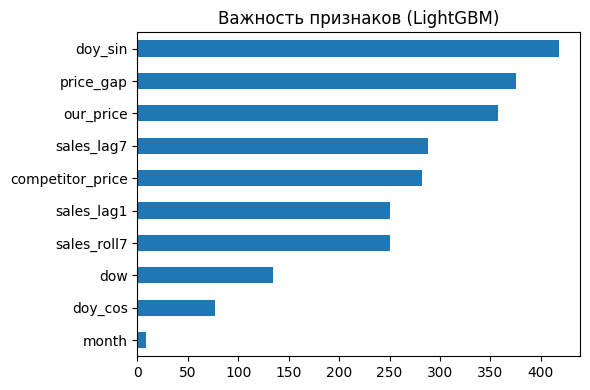

doy_sin             418
price_gap           375
our_price           358
sales_lag7          288
competitor_price    282
sales_lag1          250
sales_roll7         250
dow                 134
doy_cos              77
month                 8
dtype: int32

In [13]:
importances = pd.Series(best_lgbm.feature_importances_, index=FEATURES).sort_values(ascending=False)
importances.plot(kind="barh", figsize=(6, 4), title="Важность признаков (LightGBM)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
importances


## 7. Прогноз vs факт на тестовом периоде

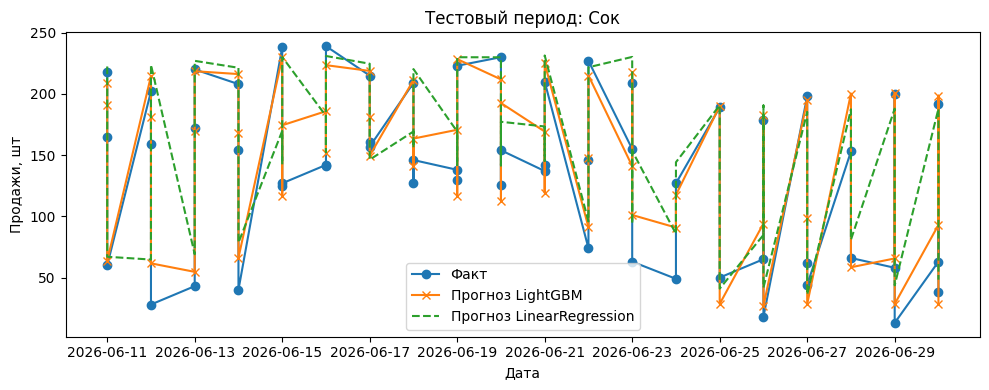

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(test_feat["date"], y_test.values, label="Факт", marker="o")
plt.plot(test_feat["date"], pred_lgbm, label="Прогноз LightGBM", marker="x")
plt.plot(test_df["date"], pred_lr, label="Прогноз LinearRegression", linestyle="--")
plt.legend()
plt.title(f"Тестовый период: {PRODUCT}")
plt.xlabel("Дата"); plt.ylabel("Продажи, шт")
plt.tight_layout()
plt.show()


## 8. Выводы

- Train/test split строился **по времени** (последние ~20% дней — тест), что корректно
  для временных рядов и соответствует логике переобучения в `model/pricing.py` (скользящее окно).
- Подбор гиперпараметров пробовали тремя встроенными способами:
  `GridSearchCV` (полный перебор), `RandomizedSearchCV` (случайная подвыборка комбинаций —
  быстрее на большой сетке) и **early stopping** LightGBM (отдельно подбирает число деревьев
  по валидации, без перебора в сетке).
- Все варианты использовали `TimeSeriesSplit`/отдельную валидационную часть, чтобы исключить
  "утечку из будущего" при подборе параметров.
- Метрики MAE/RMSE/MAPE/R² позволяют сравнить базовую линейную модель и варианты LightGBM
  на одном и том же тестовом периоде — см. итоговую таблицу выше.
- Лучшие параметры можно перенести как новые значения по умолчанию в `fit_lightgbm_sales_model`
  в `model/pricing.py`, если они стабильно выигрывают по MAE/RMSE на нескольких SKU, а не только
  на одном.
- Для надёжных выводов этот же пайплайн стоит прогнать по нескольким товарам/магазинам
  и усреднить метрики — один SKU может быть нетипичным.
- **Проверка на смещение диапазона цен.** В тестовой фикстуре
  `tests/conftest.py::lgbm_training_df` был зафиксирован баг: цена содержала
  линейный тренд, из-за чего holdout-отрезок получал цены вне диапазона
  обучения, и метрики LightGBM были ложно плохими (экстраполяция, а не
  плохая модель). В текущем ноутбуке данные генерируются через
  `generator/generate_data.py`, где цена формируется сегментно без линейного
  тренда (`_simulate_prices_segmented`), и цены тестового периода лежат
  внутри диапазона обучения, поэтому проблема не воспроизводится.
- **Валидация на внешних данных.** Приведённые выше метрики — на синтетике
  генератора. Для проверки на реальных данных создан отдельный ноутбук
  [`03_external_data_validation.ipynb`](./03_external_data_validation.ipynb),
  где прод-функции (`_fit_linear_sales_vs_price`, `fit_lightgbm_sales_model`)
  прогоняются на двух открытых датасетах: Retail Price Optimization (Kaggle,
  месячные данные, 52 SKU) и Avocado Prices (Kaggle, еженедельные данные,
  6 сущностей). Результаты подтверждают, что новые критерии надёжности
  (R²-порог для регрессии, CV-порог для LightGBM) значительно сокращают долю
  ложноположительных «надёжных» моделей на реальных данных.
